# AC-2 Parte 1 — Otimização por Enxame de Partículas (PSO)

**Cenário:** uma consultoria de engenharia foi contratada para ajudar uma empresa de logística a
otimizar a localização de 5 centros de distribuição, minimizando o custo total de entrega
(distância × demanda) para 50 clientes.

Este notebook contém as 4 missões completas, com todos os `TODO` implementados.


## Missão 1 — O PSO Básico (Partícula Única)

Objetivo: entender como uma única partícula se move, implementando a atualização de
velocidade e posição segundo a fórmula clássica do PSO:

$$v_{novo} = w \cdot v + c_1 r_1 (pBest - pos) + c_2 r_2 (gBest - pos)$$
$$pos_{novo} = pos + v_{novo}$$

Como só existe uma partícula, `pBest` e `gBest` coincidem sempre.


In [1]:
"""
MISSÃO 1: A PARTÍCULA SOLITÁRIA
Cenário: Uma partícula procurando o mínimo de f(x) = x²
Domínio: x ∈ [-10, 10]
"""

import numpy as np
import matplotlib.pyplot as plt
import random

# ==================== CONFIGURAÇÕES ====================
ITERACOES = 20
W = 0.8
C1 = 1.5
C2 = 1.5
LIMITE = 10

# ==================== FUNÇÃO OBJETIVO ====================
def funcao(x):
    return x**2  # Mínimo em x=0

# ==================== PSO UMA PARTÍCULA ====================
random.seed(42)

# Inicializar
posicao = random.uniform(-LIMITE, LIMITE)
velocidade = random.uniform(-1, 1)
fitness = funcao(posicao)

pBest_pos = posicao
pBest_fit = fitness

# gBest é o mesmo que pBest (só uma partícula)
gBest_pos = posicao
gBest_fit = fitness

historico_pos = [posicao]
historico_fit = [fitness]

print("=" * 60)
print(" PARTÍCULA SOLITÁRIA PROCURANDO O MÍNIMO")
print("=" * 60)
print(f"\nPosição inicial: {posicao:.4f}")
print(f"Fitness inicial: {fitness:.4f}\n")

for i in range(ITERACOES):
    r1 = random.random()
    r2 = random.random()

    # TODO 1: Atualizar velocidade
    # Fórmula: v_novo = w * v_atual + c1 * r1 * (pBest - pos) + c2 * r2 * (gBest - pos)
    velocidade_nova = W * velocidade + C1 * r1 * (pBest_pos - posicao) + C2 * r2 * (gBest_pos - posicao)

    # TODO 2: Atualizar posição
    # Fórmula: pos_nova = pos_atual + v_novo
    posicao_nova = posicao + velocidade_nova

    # Garantir limites
    posicao_nova = np.clip(posicao_nova, -LIMITE, LIMITE)

    # Avaliar
    fitness_novo = funcao(posicao_nova)

    # Atualizar variáveis
    posicao = posicao_nova
    velocidade = velocidade_nova
    fitness = fitness_novo

    # Atualizar pBest
    if fitness < pBest_fit:
        pBest_fit = fitness
        pBest_pos = posicao

    # Atualizar gBest (mesmo que pBest, só uma partícula)
    if fitness < gBest_fit:
        gBest_fit = fitness
        gBest_pos = posicao

    # Guardar histórico
    historico_pos.append(posicao)
    historico_fit.append(fitness)

    # Mostrar progresso
    print(f"Iteração {i+1:2d}: pos = {posicao:7.4f}, fitness = {fitness:8.4f}")

print("\n" + "=" * 60)
print(" RESULTADO FINAL")
print("=" * 60)
print(f"Posição final: {posicao:.6f}")
print(f"Fitness final: {fitness:.6f}")
print(f"Ótimo global: x = 0.000000, f(x) = 0.000000")
print(f"Erro: {abs(posicao):.6f}")


 PARTÍCULA SOLITÁRIA PROCURANDO O MÍNIMO

Posição inicial: 2.7885
Fitness inicial: 7.7759

Iteração  1: pos =  2.0286, fitness =   4.1150
Iteração  2: pos =  1.4206, fitness =   2.0180
Iteração  3: pos =  0.9342, fitness =   0.8727
Iteração  4: pos =  0.5451, fitness =   0.2971
Iteração  5: pos =  0.2338, fitness =   0.0547
Iteração  6: pos = -0.0153, fitness =   0.0002
Iteração  7: pos = -0.2145, fitness =   0.0460
Iteração  8: pos = -0.1319, fitness =   0.0174
Iteração  9: pos =  0.0769, fitness =   0.0059
Iteração 10: pos =  0.0360, fitness =   0.0013
Iteração 11: pos = -0.0348, fitness =   0.0012
Iteração 12: pos = -0.0535, fitness =   0.0029
Iteração 13: pos = -0.0576, fitness =   0.0033
Iteração 14: pos =  0.0313, fitness =   0.0010
Iteração 15: pos = -0.0049, fitness =   0.0000
Iteração 16: pos = -0.0339, fitness =   0.0011
Iteração 17: pos = -0.0166, fitness =   0.0003
Iteração 18: pos =  0.0226, fitness =   0.0005
Iteração 19: pos = -0.0054, fitness =   0.0000
Iteração 20: pos

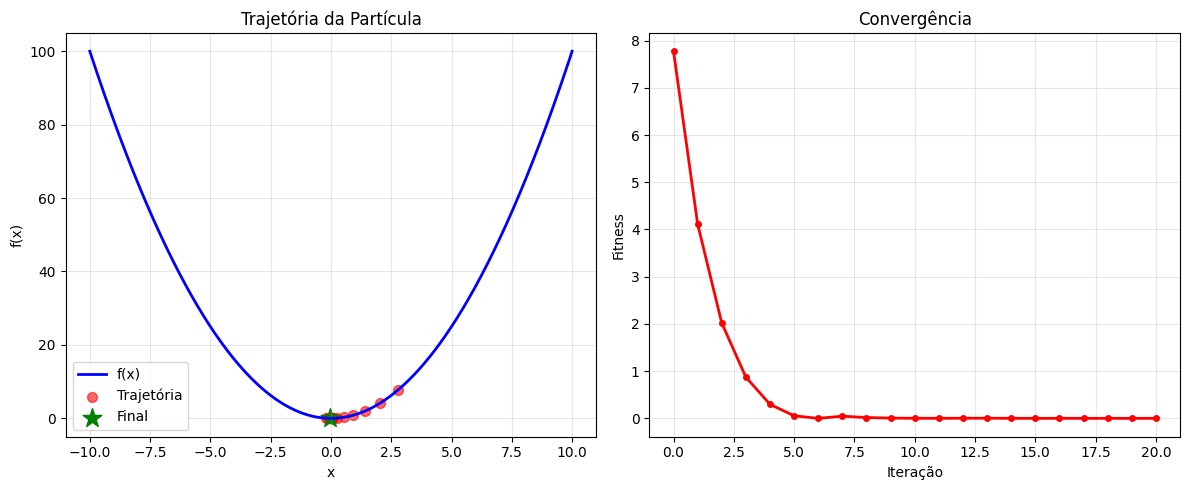

In [2]:
# Visualizar
x_plot = np.linspace(-LIMITE, LIMITE, 1000)
y_plot = funcao(x_plot)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(x_plot, y_plot, 'b-', linewidth=2, label='f(x)')
plt.scatter(historico_pos, [funcao(p) for p in historico_pos],
            color='red', s=50, alpha=0.6, label='Trajetória')
plt.scatter(posicao, fitness, color='green', s=200, marker='*', label='Final')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Trajetória da Partícula')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(ITERACOES+1), historico_fit, 'r-o', linewidth=2, markersize=4)
plt.xlabel('Iteração')
plt.ylabel('Fitness')
plt.title('Convergência')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Missão 2 — O Enxame (Múltiplas Partículas)

Agora várias partículas cooperam: cada uma guarda seu `pBest`, e todas compartilham o `gBest`
do enxame. Função de teste: **Rosenbrock**, com mínimo global em (1, 1).


In [3]:
"""
MISSÃO 2: O ENXAME DE PARTÍCULAS
Cenário: Enxame procurando o mínimo da função de Rosenbrock
f(x,y) = (1-x)² + 100*(y-x²)²
"""

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# ==================== CONFIGURAÇÕES ====================
NUM_PARTICULAS = 20
ITERACOES = 50
W = 0.7
C1 = 1.8
C2 = 1.8
X_MIN, X_MAX = -2, 2
Y_MIN, Y_MAX = -1, 3

# ==================== FUNÇÃO OBJETIVO ====================
def rosenbrock(posicao):
    x, y = posicao
    return (1 - x)**2 + 100 * (y - x**2)**2

# ==================== FUNÇÕES COMPLETADAS ====================

def criar_particula():
    """Cria uma partícula com posição e velocidade aleatórias."""
    posicao = np.array([
        np.random.uniform(X_MIN, X_MAX),
        np.random.uniform(Y_MIN, Y_MAX)
    ])
    velocidade = np.random.uniform(-0.5, 0.5, 2)
    fit = rosenbrock(posicao)
    return {
        'posicao': posicao,
        'velocidade': velocidade,
        'fitness': fit,
        'pBest_pos': posicao.copy(),
        'pBest_fit': fit
    }

def atualizar_velocidade(particula, gBest_pos):
    """Atualiza a velocidade da partícula usando a fórmula do PSO."""
    r1 = np.random.random(2)
    r2 = np.random.random(2)
    return (W * particula['velocidade']
            + C1 * r1 * (particula['pBest_pos'] - particula['posicao'])
            + C2 * r2 * (gBest_pos - particula['posicao']))

def atualizar_posicao(particula):
    """Atualiza a posição da partícula, respeitando os limites do domínio."""
    nova = particula['posicao'] + particula['velocidade']
    nova[0] = np.clip(nova[0], X_MIN, X_MAX)
    nova[1] = np.clip(nova[1], Y_MIN, Y_MAX)
    return nova

# ==================== CÓDIGO PRONTO ====================

def executar_pso():
    enxame = []
    for _ in range(NUM_PARTICULAS):
        enxame.append(criar_particula())

    melhor = min(enxame, key=lambda p: p['fitness'])
    gBest_pos = melhor['posicao'].copy()
    gBest_fit = melhor['fitness']

    historico = {'melhor': [gBest_fit], 'media': [np.mean([p['fitness'] for p in enxame])]}

    print("=" * 60)
    print(" PSO - FUNÇÃO DE ROSENBROCK")
    print("=" * 60)
    print(f"Início: Melhor fitness = {gBest_fit:.6f}")

    for iteracao in range(ITERACOES):
        for p in enxame:
            p['velocidade'] = atualizar_velocidade(p, gBest_pos)
            p['posicao'] = atualizar_posicao(p)
            p['fitness'] = rosenbrock(p['posicao'])

            if p['fitness'] < p['pBest_fit']:
                p['pBest_fit'] = p['fitness']
                p['pBest_pos'] = p['posicao'].copy()

            if p['fitness'] < gBest_fit:
                gBest_fit = p['fitness']
                gBest_pos = p['posicao'].copy()

        historico['melhor'].append(gBest_fit)
        historico['media'].append(np.mean([p['fitness'] for p in enxame]))

        if (iteracao + 1) % 10 == 0:
            print(f"Iteração {iteracao+1:3d}: Melhor = {gBest_fit:.6f}")

    print(f"\nFim: Melhor fitness = {gBest_fit:.6f}")
    print(f"Ótimo global: f(1,1) = 0.000000")

    return gBest_pos, gBest_fit, historico, enxame

# ==================== EXECUTAR ====================
best_pos, best_fit, historico, enxame = executar_pso()
print("Melhor posição encontrada:", best_pos)


 PSO - FUNÇÃO DE ROSENBROCK
Início: Melhor fitness = 3.363231
Iteração  10: Melhor = 0.213414
Iteração  20: Melhor = 0.182157
Iteração  30: Melhor = 0.000468
Iteração  40: Melhor = 0.000468
Iteração  50: Melhor = 0.000348

Fim: Melhor fitness = 0.000348
Ótimo global: f(1,1) = 0.000000
Melhor posição encontrada: [1.01106523 1.02075228]


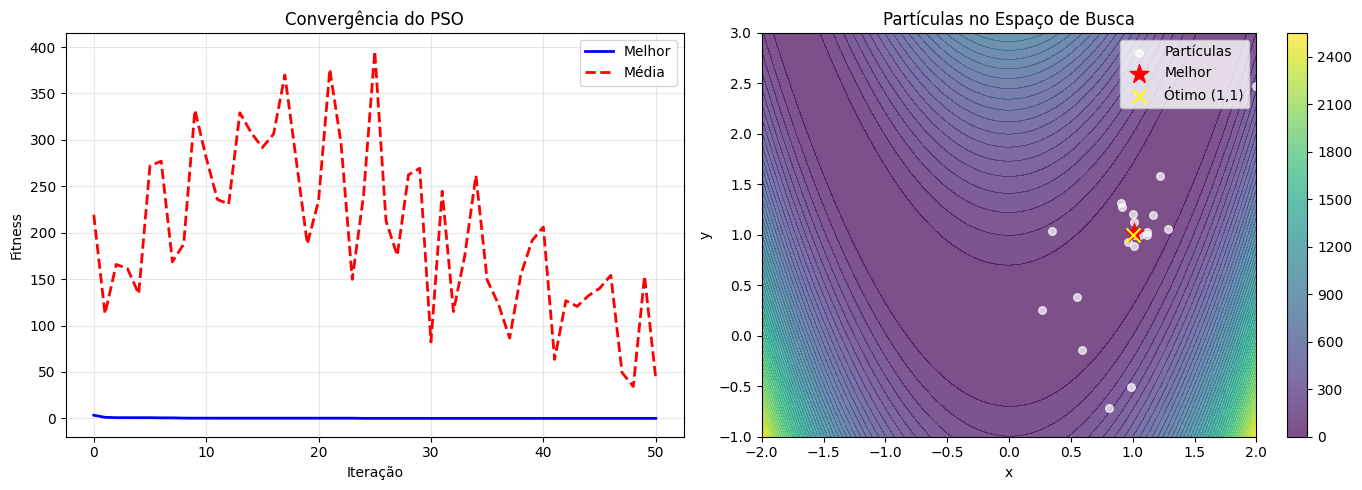

In [4]:
# Visualizar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(historico['melhor'], 'b-', linewidth=2, label='Melhor')
ax1.plot(historico['media'], 'r--', linewidth=2, label='Média')
ax1.set_xlabel('Iteração')
ax1.set_ylabel('Fitness')
ax1.set_title('Convergência do PSO')
ax1.legend()
ax1.grid(True, alpha=0.3)

x_pos = [p['posicao'][0] for p in enxame]
y_pos = [p['posicao'][1] for p in enxame]

x_plot = np.linspace(X_MIN, X_MAX, 100)
y_plot = np.linspace(Y_MIN, Y_MAX, 100)
X, Y = np.meshgrid(x_plot, y_plot)
Z = np.array([[rosenbrock([xi, yi]) for xi, yi in zip(row_x, row_y)]
              for row_x, row_y in zip(X, Y)])

contour = ax2.contourf(X, Y, Z, levels=50, cmap='viridis', alpha=0.7)
ax2.scatter(x_pos, y_pos, color='white', s=30, alpha=0.7, label='Partículas')
ax2.scatter(best_pos[0], best_pos[1], color='red', s=200,
           marker='*', label='Melhor')
ax2.scatter(1, 1, color='yellow', s=100, marker='x', label='Ótimo (1,1)')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Partículas no Espaço de Busca')
ax2.legend()
plt.colorbar(contour, ax=ax2)

plt.tight_layout()
plt.show()


## Missão 3 — O Problema Corporativo (Otimização Logística)

Aqui aplicamos o PSO ao problema real: encontrar as coordenadas de 5 centros de distribuição
que minimizam o custo total de entrega (distância × demanda) para 50 clientes (10 variáveis:
5 centros × 2 coordenadas).

In [5]:
"""
MISSÃO 3: OTIMIZAÇÃO LOGÍSTICA
Problema: Encontrar a localização de 5 centros de distribuição
que minimiza o custo de entrega para 50 clientes.
"""

import numpy as np
import matplotlib.pyplot as plt
import time

# ==================== CONFIGURAÇÕES ====================
NUM_CLIENTES = 50
NUM_CENTROS = 5
NUM_PARTICULAS = 30
ITERACOES = 100
W = 0.7
C1 = 1.8
C2 = 1.8
LIMITE = 10  # Coordenadas de 0 a 10

# ==================== GERAR DADOS ====================
np.random.seed(42)
clientes = np.random.rand(NUM_CLIENTES, 2) * LIMITE
demandas = np.random.randint(1, 100, NUM_CLIENTES)

print("=" * 60)
print(" OPTIMUS TECH - LOGÍSTICA INTELIGENTE")
print("=" * 60)
print(f"\n DADOS DO PROBLEMA:")
print(f"   - {NUM_CLIENTES} clientes")
print(f"   - {NUM_CENTROS} centros de distribuição")
print(f"   - Demanda média: {np.mean(demandas):.1f} unidades")

DIM = NUM_CENTROS * 2

# ==================== FUNÇÃO OBJETIVO ====================
def fitness(posicoes_centros):
    """
    Calcula o custo total de entrega.
    posicoes_centros: array de 10 elementos [x1,y1,x2,y2,...,x5,y5]
    Retorna: custo_total
    """
    # TODO 1: Converter para lista de centros
    centros = [posicoes_centros[2*i:2*i+2] for i in range(NUM_CENTROS)]

    custo_total = 0
    for cliente, demanda in zip(clientes, demandas):
        # TODO 2: Encontrar o centro mais próximo / TODO 3: distância
        distancias = [np.sqrt((c[0] - cliente[0])**2 + (c[1] - cliente[1])**2)
                      for c in centros]
        dist_min = min(distancias)

        # TODO 4: Adicionar ao custo total
        custo_total += dist_min * demanda

    return custo_total

# ==================== PSO COMPLETO ====================

# TODO 5: Criar uma partícula (10 dimensões)
def criar_particula():
    posicao = np.random.uniform(0, LIMITE, DIM)
    velocidade = np.random.uniform(-0.5, 0.5, DIM)
    fit = fitness(posicao)
    return {
        'posicao': posicao,
        'velocidade': velocidade,
        'fitness': fit,
        'pBest_pos': posicao.copy(),
        'pBest_fit': fit
    }

# TODO 6: Atualizar velocidade (10 dimensões)
def atualizar_velocidade(particula, gBest_pos):
    r1 = np.random.random(DIM)
    r2 = np.random.random(DIM)
    return (W * particula['velocidade']
            + C1 * r1 * (particula['pBest_pos'] - particula['posicao'])
            + C2 * r2 * (gBest_pos - particula['posicao']))

# TODO 7: Atualizar posição (10 dimensões) com limites
def atualizar_posicao(particula):
    nova = particula['posicao'] + particula['velocidade']
    return np.clip(nova, 0, LIMITE)

# ==================== EXECUTAR ====================
def executar_pso():
    enxame = []
    for _ in range(NUM_PARTICULAS):
        enxame.append(criar_particula())

    melhor = min(enxame, key=lambda p: p['fitness'])
    gBest_pos = melhor['posicao'].copy()
    gBest_fit = melhor['fitness']

    historico = [gBest_fit]

    print("\n OTIMIZANDO...")
    start_time = time.time()

    for iteracao in range(ITERACOES):
        for p in enxame:
            p['velocidade'] = atualizar_velocidade(p, gBest_pos)
            p['posicao'] = atualizar_posicao(p)
            p['fitness'] = fitness(p['posicao'])

            if p['fitness'] < p['pBest_fit']:
                p['pBest_fit'] = p['fitness']
                p['pBest_pos'] = p['posicao'].copy()

            if p['fitness'] < gBest_fit:
                gBest_fit = p['fitness']
                gBest_pos = p['posicao'].copy()

        historico.append(gBest_fit)

        if (iteracao + 1) % 20 == 0:
            print(f"  Iteração {iteracao+1:3d}: Custo = {gBest_fit:.2f}")

    execution_time = time.time() - start_time

    return gBest_pos, gBest_fit, historico, execution_time

# ==================== RESULTADOS ====================
best_pos, best_fit, historico, exec_time = executar_pso()

centros = []
for i in range(NUM_CENTROS):
    centros.append([best_pos[2*i], best_pos[2*i+1]])

# Referência: custo médio de soluções aleatórias, para comparação
np.random.seed(1)
custos_aleatorios = [fitness(np.random.uniform(0, LIMITE, DIM)) for _ in range(200)]
custo_referencia = float(np.mean(custos_aleatorios))

print(f"\n RESULTADO FINAL:")
print(f"   Tempo de execução: {exec_time:.2f} segundos")
print(f"   Custo total (PSO): {best_fit:.2f}")
print(f"   Custo médio de soluções aleatórias (referência): {custo_referencia:.2f}")
print(f"   Melhoria: {100*(1 - best_fit/custo_referencia):.1f}%")
print(f"   Centros de distribuição:")
for i, centro in enumerate(centros):
    print(f"      Centro {i+1}: ({centro[0]:.2f}, {centro[1]:.2f})")


 OPTIMUS TECH - LOGÍSTICA INTELIGENTE

 DADOS DO PROBLEMA:
   - 50 clientes
   - 5 centros de distribuição
   - Demanda média: 51.0 unidades

 OTIMIZANDO...
  Iteração  20: Custo = 3716.12


  Iteração  40: Custo = 3581.58
  Iteração  60: Custo = 3526.28


  Iteração  80: Custo = 3517.56
  Iteração 100: Custo = 3514.93

 RESULTADO FINAL:
   Tempo de execução: 0.65 segundos
   Custo total (PSO): 3514.93
   Custo médio de soluções aleatórias (referência): 6540.80
   Melhoria: 46.3%
   Centros de distribuição:
      Centro 1: (2.70, 5.32)
      Centro 2: (0.59, 8.65)
      Centro 3: (5.47, 1.76)
      Centro 4: (0.90, 1.94)
      Centro 5: (7.74, 6.12)


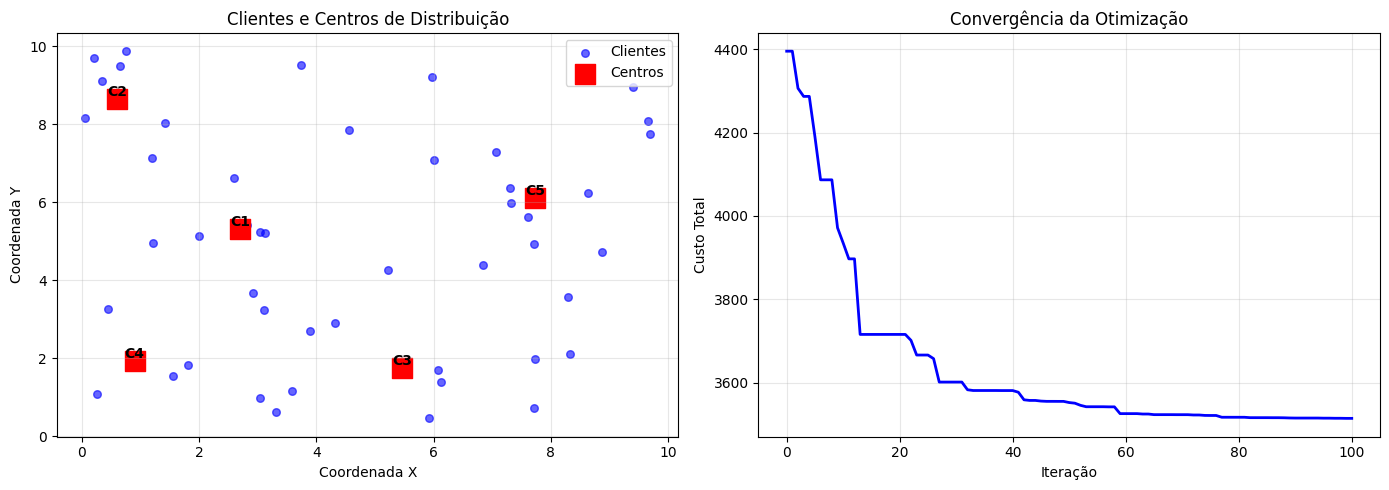

In [6]:
# ==================== VISUALIZAÇÃO ====================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(clientes[:, 0], clientes[:, 1], c='blue', s=30, alpha=0.6, label='Clientes')
for i, centro in enumerate(centros):
    ax1.scatter(centro[0], centro[1], c='red', s=200, marker='s',
               label='Centros' if i == 0 else "")
    ax1.annotate(f'C{i+1}', (centro[0], centro[1]), fontsize=10,
                ha='center', va='bottom', weight='bold')

ax1.set_xlabel('Coordenada X')
ax1.set_ylabel('Coordenada Y')
ax1.set_title('Clientes e Centros de Distribuição')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(historico, 'b-', linewidth=2)
ax2.set_xlabel('Iteração')
ax2.set_ylabel('Custo Total')
ax2.set_title('Convergência da Otimização')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Missão 4 — Otimização de Parâmetros

Comparamos diferentes combinações de `w` (inércia), `c1` (cognitivo), `c2` (social) e número
de partículas, rodando cada configuração 5 vezes para obter uma média robusta.

In [7]:
"""
MISSÃO 4: OTIMIZAÇÃO DOS PARÂMETROS DO PSO
Objetivo: Encontrar a melhor combinação de parâmetros para o problema logístico
"""

import numpy as np
import matplotlib.pyplot as plt

# ==================== CONFIGURAÇÕES ====================
BASE_PARAMS = {
    'num_particulas': 30,
    'iteracoes': 50,
    'w': 0.7,
    'c1': 1.8,
    'c2': 1.8,
    'limite': 10,
    'num_centros': 5,
    'num_clientes': 50
}

EXPERIMENTOS = [
    {'nome': 'Padrão', 'params': BASE_PARAMS.copy()},
    {'nome': 'Inércia Alta', 'params': {**BASE_PARAMS, 'w': 0.9}},
    {'nome': 'Inércia Baixa', 'params': {**BASE_PARAMS, 'w': 0.5}},
    {'nome': 'Cognitivo Alto', 'params': {**BASE_PARAMS, 'c1': 2.5}},
    {'nome': 'Social Alto', 'params': {**BASE_PARAMS, 'c2': 2.5}},
    {'nome': 'Mais Partículas', 'params': {**BASE_PARAMS, 'num_particulas': 60}},
]

# ==================== GERAR DADOS ====================
np.random.seed(42)
clientes = np.random.rand(BASE_PARAMS['num_clientes'], 2) * BASE_PARAMS['limite']
demandas = np.random.randint(1, 100, BASE_PARAMS['num_clientes'])

# ==================== FUNÇÃO FITNESS ====================
def fitness(posicoes_centros, clientes, demandas, num_centros):
    centros = [posicoes_centros[2*i:2*i+2] for i in range(num_centros)]
    custo_total = 0
    for cliente, demanda in zip(clientes, demandas):
        distancias = [np.sqrt((c[0] - cliente[0])**2 + (c[1] - cliente[1])**2)
                      for c in centros]
        custo_total += min(distancias) * demanda
    return custo_total

# ==================== PSO ====================
def executar_pso(params, clientes, demandas):
    num_particulas = params['num_particulas']
    iteracoes = params['iteracoes']
    w = params['w']
    c1 = params['c1']
    c2 = params['c2']
    limite = params['limite']
    num_centros = params['num_centros']
    dim = num_centros * 2

    enxame = []
    for _ in range(num_particulas):
        posicao = np.random.uniform(0, limite, dim)
        velocidade = np.random.uniform(-0.5, 0.5, dim)
        fit = fitness(posicao, clientes, demandas, num_centros)
        enxame.append({
            'posicao': posicao,
            'velocidade': velocidade,
            'fitness': fit,
            'pBest_pos': posicao.copy(),
            'pBest_fit': fit
        })

    melhor = min(enxame, key=lambda p: p['fitness'])
    gBest_pos = melhor['posicao'].copy()
    gBest_fit = melhor['fitness']

    historico = [gBest_fit]

    for _ in range(iteracoes):
        for p in enxame:
            r1 = np.random.random(dim)
            r2 = np.random.random(dim)

            p['velocidade'] = w * p['velocidade'] + \
                             c1 * r1 * (p['pBest_pos'] - p['posicao']) + \
                             c2 * r2 * (gBest_pos - p['posicao'])

            p['posicao'] = np.clip(p['posicao'] + p['velocidade'], 0, limite)
            p['fitness'] = fitness(p['posicao'], clientes, demandas, num_centros)

            if p['fitness'] < p['pBest_fit']:
                p['pBest_fit'] = p['fitness']
                p['pBest_pos'] = p['posicao'].copy()

            if p['fitness'] < gBest_fit:
                gBest_fit = p['fitness']
                gBest_pos = p['posicao'].copy()

        historico.append(gBest_fit)

    return gBest_fit, historico

# ==================== EXECUTAR EXPERIMENTOS ====================
print("=" * 60)
print(" EXPERIMENTOS COM PARÂMETROS DO PSO")
print("=" * 60)

resultados = {}

for exp in EXPERIMENTOS:
    print(f"\n Experimento: {exp['nome']}")
    print(f"   Parâmetros: w={exp['params']['w']}, c1={exp['params']['c1']}, "
          f"c2={exp['params']['c2']}, partículas={exp['params']['num_particulas']}")

    execucoes = 5
    custos = []
    historicos = []

    for i in range(execucoes):
        custo_final, historico = executar_pso(exp['params'], clientes, demandas)
        custos.append(custo_final)
        historicos.append(historico)

    resultados[exp['nome']] = {
        'custo_medio': np.mean(custos),
        'custo_std': np.std(custos),
        'melhor_custo': min(custos),
        'pior_custo': max(custos),
        'historico': np.mean(historicos, axis=0)
    }

    print(f"   Custo médio: {resultados[exp['nome']]['custo_medio']:.2f} ± "
          f"{resultados[exp['nome']]['custo_std']:.2f}")

# ==================== ANÁLISE DOS RESULTADOS ====================
print("\n" + "=" * 60)
print(" ANÁLISE DOS RESULTADOS")
print("=" * 60)

print("\n| Experimento        | Custo Médio | Melhor Custo | Pior Custo  |")
print("|--------------------|-------------|--------------|-------------|")
for nome, data in resultados.items():
    print(f"| {nome:<18} | {data['custo_medio']:10.2f} | {data['melhor_custo']:12.2f} | "
          f"{data['pior_custo']:11.2f} |")


 EXPERIMENTOS COM PARÂMETROS DO PSO

 Experimento: Padrão
   Parâmetros: w=0.7, c1=1.8, c2=1.8, partículas=30


   Custo médio: 3638.88 ± 73.07

 Experimento: Inércia Alta
   Parâmetros: w=0.9, c1=1.8, c2=1.8, partículas=30


   Custo médio: 3951.15 ± 139.29

 Experimento: Inércia Baixa
   Parâmetros: w=0.5, c1=1.8, c2=1.8, partículas=30


   Custo médio: 3647.04 ± 91.90

 Experimento: Cognitivo Alto
   Parâmetros: w=0.7, c1=2.5, c2=1.8, partículas=30


   Custo médio: 3750.04 ± 55.77

 Experimento: Social Alto
   Parâmetros: w=0.7, c1=1.8, c2=2.5, partículas=30


   Custo médio: 3952.36 ± 67.52

 Experimento: Mais Partículas
   Parâmetros: w=0.7, c1=1.8, c2=1.8, partículas=60


   Custo médio: 3635.02 ± 57.41

 ANÁLISE DOS RESULTADOS

| Experimento        | Custo Médio | Melhor Custo | Pior Custo  |
|--------------------|-------------|--------------|-------------|
| Padrão             |    3638.88 |      3547.08 |     3712.66 |
| Inércia Alta       |    3951.15 |      3772.40 |     4145.73 |
| Inércia Baixa      |    3647.04 |      3514.29 |     3797.89 |
| Cognitivo Alto     |    3750.04 |      3671.45 |     3808.38 |
| Social Alto        |    3952.36 |      3890.59 |     4051.99 |
| Mais Partículas    |    3635.02 |      3523.28 |     3677.28 |


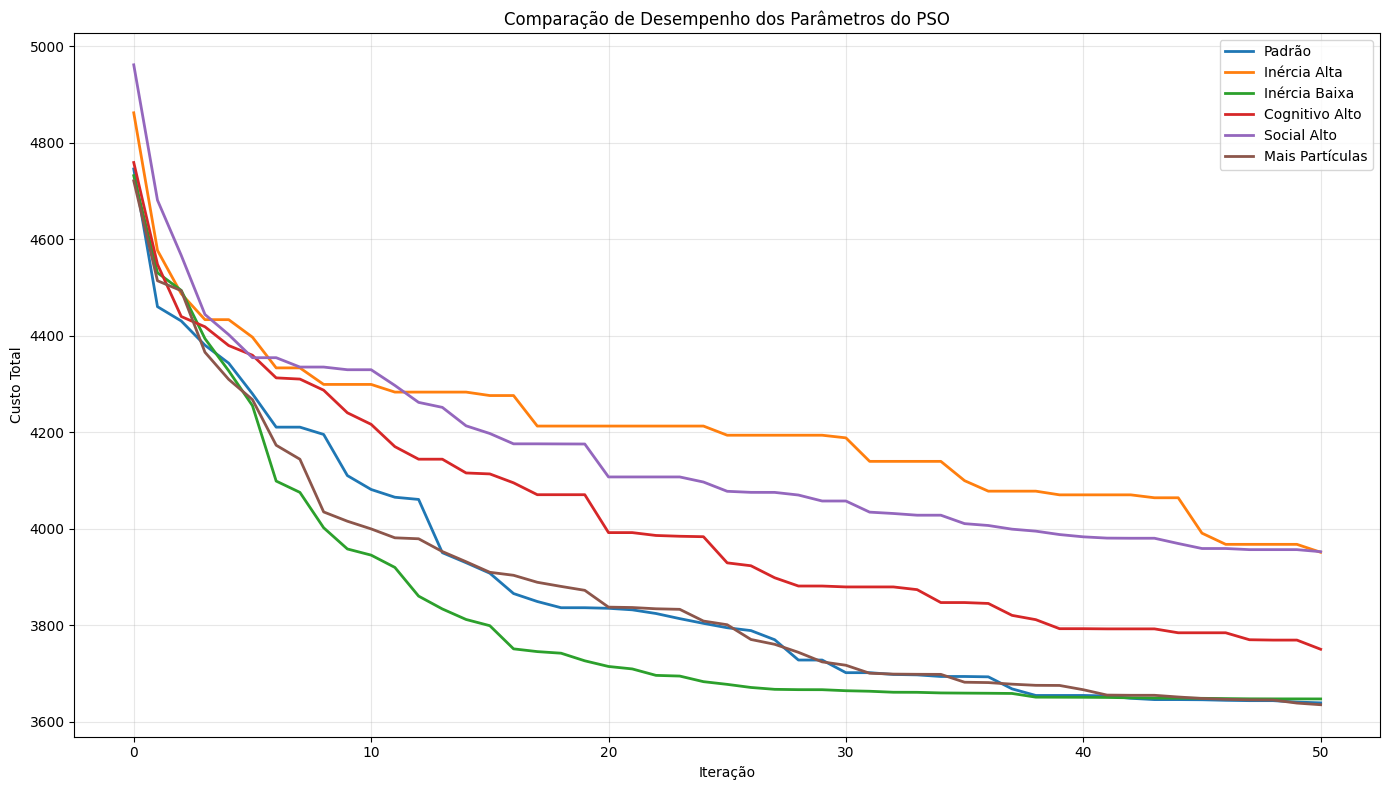

In [8]:
# ==================== VISUALIZAÇÃO ====================
plt.figure(figsize=(14, 8))

for nome, data in resultados.items():
    plt.plot(data['historico'], linewidth=2, label=nome)

plt.xlabel('Iteração')
plt.ylabel('Custo Total')
plt.title('Comparação de Desempenho dos Parâmetros do PSO')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [9]:
# ==================== RELATÓRIO ====================
print("\n" + "=" * 60)
print(" ANÁLISE E CONCLUSÕES")
print("=" * 60)
print("\n1. Qual configuração obteve o MELHOR resultado?")
print("   →", min(resultados.items(), key=lambda x: x[1]['custo_medio'])[0])

print("\n2. Qual configuração obteve o PIOR resultado?")
print("   →", max(resultados.items(), key=lambda x: x[1]['custo_medio'])[0])



 ANÁLISE E CONCLUSÕES

1. Qual configuração obteve o MELHOR resultado?
   → Mais Partículas

2. Qual configuração obteve o PIOR resultado?
   → Social Alto
